# Video Preprocessing and Macaque Detection

This notebook handles:
1. Video preprocessing and exploration
2. Object detection using YOLO
3. Basic tracking with simple tracker
4. Feature extraction for individual identification


## 1. Explore Available Videos

In [1]:
import sys
import os
sys.path.append('../src')

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

from macaque_tracker.detector import MacaqueDetector
from macaque_tracker.tracker import SimpleTracker, TrackletManager
from macaque_tracker.video_utils import VideoProcessor, find_video_files

plt.style.use('default')
sns.set_palette("husl")

In [2]:
# Find all video files
data_dir = "../data/raw"
video_files = find_video_files(data_dir)

print(f"Found {len(video_files)} video files:")
for i, video in enumerate(video_files[:10]):  # Show first 10
    print(f"{i+1:2d}. {Path(video).name} ({Path(video).parent.name})")
    
if len(video_files) > 10:
    print(f"... and {len(video_files) - 10} more files")

Found 15 video files:
 1. GH010369.MP4 (GoPro Table 4)
 2. GH010372.MP4 (GoPro Table 4)
 3. GH010374.MP4 (GoPro Table 4)
 4. GH010371.MP4 (GoPro Table 5)
 5. GH010373.MP4 (GoPro Table 5)
 6. GH010375.MP4 (GoPro Table 5)
 7. GH010378.MP4 (GoPro Table 5)
 8. GH010390.MP4 (GoPro Table 6)
 9. GH010392.MP4 (GoPro Table 6)
10. GH010393.MP4 (GoPro Table 6)
... and 5 more files


In [3]:
# Get video info for first few files
video_info = []

for video_path in video_files[:5]:  # Check first 5 videos
    try:
        with VideoProcessor(video_path) as processor:
            info = {
                'filename': Path(video_path).name,
                'location': Path(video_path).parent.name,
                'duration_seconds': processor.duration,
                'fps': processor.fps,
                'frame_count': processor.frame_count,
                'file_size_mb': os.path.getsize(video_path) / (1024*1024)
            }
            video_info.append(info)
    except Exception as e:
        print(f"Error processing {video_path}: {e}")

df_videos = pd.DataFrame(video_info)
print("\nVideo Information:")
display(df_videos)


Video Information:


,filename,location,duration_seconds,fps,frame_count,file_size_mb
0,GH010369.MP4,GoPro Table 4,3.003000,59.94006,180,21.931665
1,GH010372.MP4,GoPro Table 4,1.718383,59.94006,103,12.948002
2,GH010374.MP4,GoPro Table 4,3.436767,59.94006,206,24.968781
3,GH010371.MP4,GoPro Table 5,249.782867,59.94006,14972,1795.107083
4,GH010373.MP4,GoPro Table 5,1.735067,59.94006,104,13.006906


## 2. Initialize Detection and Tracking Components

In [4]:
# Initialize detector and tracker
detector = MacaqueDetector(confidence=0.3)  # Lower confidence for more detections
tracker = SimpleTracker(max_disappeared=10, max_distance=150)
tracklet_manager = TrackletManager()

print("✓ Detector and tracker initialized")
print(f"✓ Using model: YOLOv8n")
print(f"✓ Detection confidence threshold: {detector.confidence}")

✓ Detector and tracker initialized
✓ Using model: YOLOv8n
✓ Detection confidence threshold: 0.3


## 3. Process Sample Video

In [5]:
# Select a video to process (choose first available)
for sample_video in video_files:
    print(f"Processing: {Path(sample_video).name}")
    
    # Process video
    detections_data = []
    frame_skip = 5  # Process every 5th frame to speed up processing
    
    with VideoProcessor(sample_video) as processor:
        total_frames = processor.frame_count#min(300000, processor.frame_count)  # Limit to first 300 frames for demo
        
        with tqdm(total=total_frames//frame_skip, desc="Processing frames") as pbar:
            for frame_num, frame in processor.frame_generator(0, total_frames):
                if frame_num % frame_skip != 0:
                    continue
                    
                # Detect objects
                detections = detector.detect_primates(frame)
                
                # Extract features for each detection
                for detection in detections:
                    features = detector.extract_features(frame, detection['bbox'])
                    detection['features'] = features
                
                # Update tracker
                tracked_objects = tracker.update(detections)
                
                # Store detection data
                for detection in detections:
                    if 'track_id' in detection:
                        detection_record = {
                            'frame': frame_num,
                            'track_id': detection['track_id'],
                            'bbox_x1': detection['bbox'][0],
                            'bbox_y1': detection['bbox'][1],
                            'bbox_x2': detection['bbox'][2],
                            'bbox_y2': detection['bbox'][3],
                            'confidence': detection['confidence'],
                            'center_x': detection['center'][0],
                            'center_y': detection['center'][1]
                        }
                        detections_data.append(detection_record)
                        
                        # Add to tracklet manager
                        tracklet_manager.add_detection(detection['track_id'], frame_num, detection)
                
                pbar.update(1)
    
    # Convert to DataFrame
    df_detections = pd.DataFrame(detections_data)
    print(f"\n✓ Processed {total_frames} frames")
    print(f"✓ Found {len(df_detections)} detections")
    try:
        print(f"✓ Identified {df_detections['track_id'].nunique()} tracks")
        break
    except:
        # no detections in this video
        continue
else:
    print("No video files found!")

Processing: GH010369.MP4


Processing frames:   0%|          | 0/36 [00:00<?, ?it/s]


0: 480x640 1 person, 1 bench, 46.7ms
Speed: 2.1ms preprocess, 46.7ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 bench, 42.5ms
Speed: 2.2ms preprocess, 42.5ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 2 benchs, 42.1ms
Speed: 1.8ms preprocess, 42.1ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 bench, 43.1ms
Speed: 2.3ms preprocess, 43.1ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 2 benchs, 43.2ms
Speed: 1.8ms preprocess, 43.2ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 bench, 51.8ms
Speed: 3.0ms preprocess, 51.8ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 bench, 44.7ms
Speed: 2.1ms preprocess, 44.7ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 1 bench, 44.3ms
Speed: 1.9ms pr

Processing frames:   0%|          | 0/20 [00:00<?, ?it/s]


0: 480x640 2 benchs, 39.0ms
Speed: 1.6ms preprocess, 39.0ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 benchs, 38.2ms
Speed: 1.9ms preprocess, 38.2ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 benchs, 39.7ms
Speed: 1.8ms preprocess, 39.7ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 benchs, 40.3ms
Speed: 1.7ms preprocess, 40.3ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 benchs, 41.0ms
Speed: 2.2ms preprocess, 41.0ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 benchs, 43.2ms
Speed: 1.8ms preprocess, 43.2ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 benchs, 42.1ms
Speed: 1.8ms preprocess, 42.1ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 benchs, 40.1ms
Speed: 1.7ms preprocess, 40.1ms inference, 0.6ms postprocess per image at shape (1, 3, 48

Processing frames:   0%|          | 0/41 [00:00<?, ?it/s]


0: 480x640 1 person, 2 benchs, 39.5ms
Speed: 1.7ms preprocess, 39.5ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 2 benchs, 42.4ms
Speed: 2.4ms preprocess, 42.4ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 2 benchs, 42.2ms
Speed: 2.2ms preprocess, 42.2ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 2 benchs, 41.8ms
Speed: 2.2ms preprocess, 41.8ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 2 benchs, 40.5ms
Speed: 1.8ms preprocess, 40.5ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 2 benchs, 44.4ms
Speed: 1.6ms preprocess, 44.4ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 2 benchs, 41.5ms
Speed: 1.6ms preprocess, 41.5ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 2 benchs, 43.1ms
Speed: 1.

Processing frames:   0%|          | 0/2994 [00:00<?, ?it/s]


0: 480x640 1 bench, 39.5ms
Speed: 1.7ms preprocess, 39.5ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 bench, 40.7ms
Speed: 1.7ms preprocess, 40.7ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 bench, 42.6ms
Speed: 1.7ms preprocess, 42.6ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 bench, 39.9ms
Speed: 1.8ms preprocess, 39.9ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 bench, 39.1ms
Speed: 1.8ms preprocess, 39.1ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 bench, 41.0ms
Speed: 1.6ms preprocess, 41.0ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 bench, 40.3ms
Speed: 1.6ms preprocess, 40.3ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 bench, 40.1ms
Speed: 1.7ms preprocess, 40.1ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)


## 4. Analyze Detection Results

In [6]:
if not df_detections.empty:
    # Basic statistics
    print("Detection Statistics:")
    print(f"Total detections: {len(df_detections)}")
    print(f"Unique tracks: {df_detections['track_id'].nunique()}")
    print(f"Average confidence: {df_detections['confidence'].mean():.3f}")
    print(f"Frame range: {df_detections['frame'].min()} - {df_detections['frame'].max()}")
    
    # Track length analysis
    track_lengths = df_detections.groupby('track_id').size()
    print(f"\nTrack Length Statistics:")
    print(f"Mean track length: {track_lengths.mean():.1f} detections")
    print(f"Median track length: {track_lengths.median():.1f} detections")
    print(f"Longest track: {track_lengths.max()} detections")
    
    # Show sample data
    print("\nSample Detections:")
    display(df_detections.head(10))

Detection Statistics:
Total detections: 391
Unique tracks: 23
Average confidence: 0.490
Frame range: 1310 - 9070

Track Length Statistics:
Mean track length: 17.0 detections
Median track length: 7.0 detections
Longest track: 92 detections

Sample Detections:


,frame,track_id,bbox_x1,bbox_y1,bbox_x2,bbox_y2,confidence,center_x,center_y
0,1310,0,888,653,1027,796,0.537927,957.579346,724.937744
1,1310,1,886,651,1026,797,0.305222,956.577393,724.718018
2,1315,1,886,654,1026,796,0.792952,956.287109,725.556641
3,1320,1,881,651,1025,796,0.716877,953.549316,724.037109
4,1325,1,878,651,1022,797,0.778482,950.515869,724.231079
5,1330,1,877,650,1018,795,0.680294,948.476624,722.777466
6,3715,2,927,747,977,795,0.309912,952.449280,771.133667
7,3725,2,933,748,991,794,0.307917,962.354248,771.752930
8,3730,2,941,748,992,791,0.324269,966.797791,770.117615
9,3765,2,968,741,1032,792,0.349525,1000.267639,767.163086


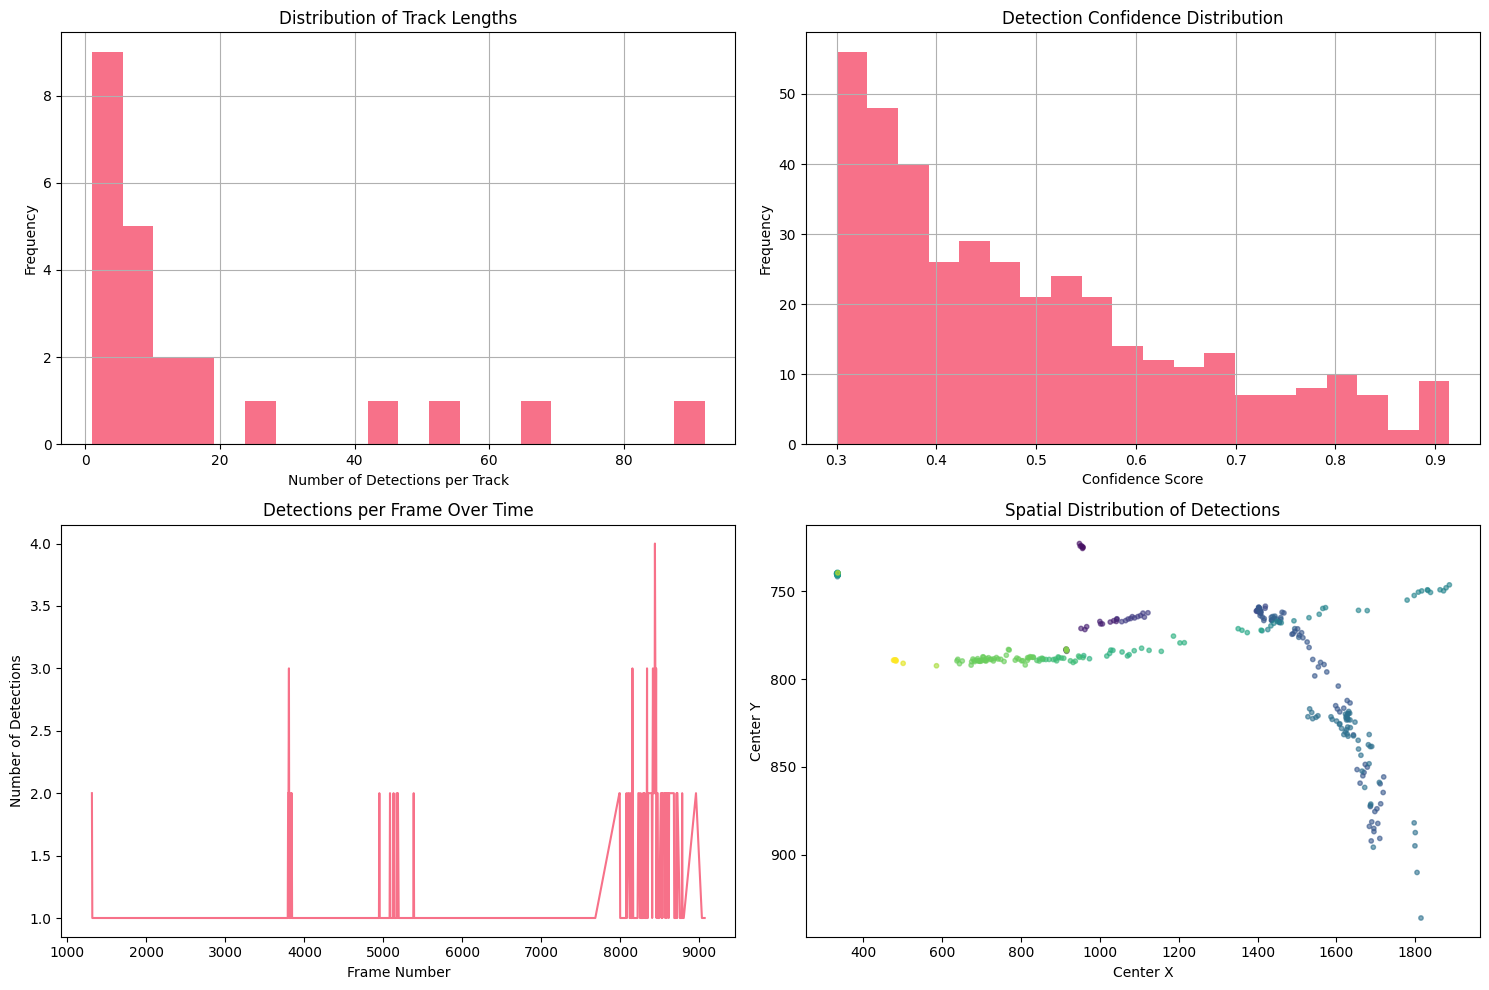

In [7]:
# Visualize detection patterns
if not df_detections.empty:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Track lengths distribution
    track_lengths.hist(bins=20, ax=axes[0,0])
    axes[0,0].set_title('Distribution of Track Lengths')
    axes[0,0].set_xlabel('Number of Detections per Track')
    axes[0,0].set_ylabel('Frequency')
    
    # Confidence distribution
    df_detections['confidence'].hist(bins=20, ax=axes[0,1])
    axes[0,1].set_title('Detection Confidence Distribution')
    axes[0,1].set_xlabel('Confidence Score')
    axes[0,1].set_ylabel('Frequency')
    
    # Detections over time
    detections_per_frame = df_detections.groupby('frame').size()
    detections_per_frame.plot(ax=axes[1,0])
    axes[1,0].set_title('Detections per Frame Over Time')
    axes[1,0].set_xlabel('Frame Number')
    axes[1,0].set_ylabel('Number of Detections')
    
    # Spatial distribution of detections
    axes[1,1].scatter(df_detections['center_x'], df_detections['center_y'], 
                      c=df_detections['track_id'], alpha=0.6, s=10)
    axes[1,1].set_title('Spatial Distribution of Detections')
    axes[1,1].set_xlabel('Center X')
    axes[1,1].set_ylabel('Center Y')
    axes[1,1].invert_yaxis()  # Invert Y axis to match image coordinates
    
    plt.tight_layout()
    plt.show()

## 5. Save Results for Next Steps

In [8]:
# Create output directory
output_dir = Path("../output")
output_dir.mkdir(exist_ok=True)

# Save detection results
if not df_detections.empty:
    detections_file = output_dir / f"detections_{Path(sample_video).stem}.csv"
    df_detections.to_csv(detections_file, index=False)
    print(f"✓ Saved detections to {detections_file}")
    
    # Save video info
    video_info_file = output_dir / "video_info.csv"
    df_videos.to_csv(video_info_file, index=False)
    print(f"✓ Saved video info to {video_info_file}")
    
    # Extract and save tracklet features for clustering
    tracklet_features = tracklet_manager.get_all_tracklet_features()
    
    # Save features as numpy arrays
    features_file = output_dir / f"tracklet_features_{Path(sample_video).stem}.npz"
    np.savez(features_file, **{f"track_{k}": v for k, v in tracklet_features.items()})
    print(f"✓ Saved tracklet features to {features_file}")
    
    # Save track mapping for reference
    track_mapping = pd.DataFrame([
        {'track_id': k, 'feature_length': len(v)} 
        for k, v in tracklet_features.items()
    ])
    track_mapping_file = output_dir / f"track_mapping_{Path(sample_video).stem}.csv"
    track_mapping.to_csv(track_mapping_file, index=False)
    print(f"✓ Saved track mapping to {track_mapping_file}")
else:
    print("No detections to save")

✓ Saved detections to ../output/detections_GH010371.csv
✓ Saved video info to ../output/video_info.csv
✓ Saved tracklet features to ../output/tracklet_features_GH010371.npz
✓ Saved track mapping to ../output/track_mapping_GH010371.csv


## 6. Preview Sample Detections

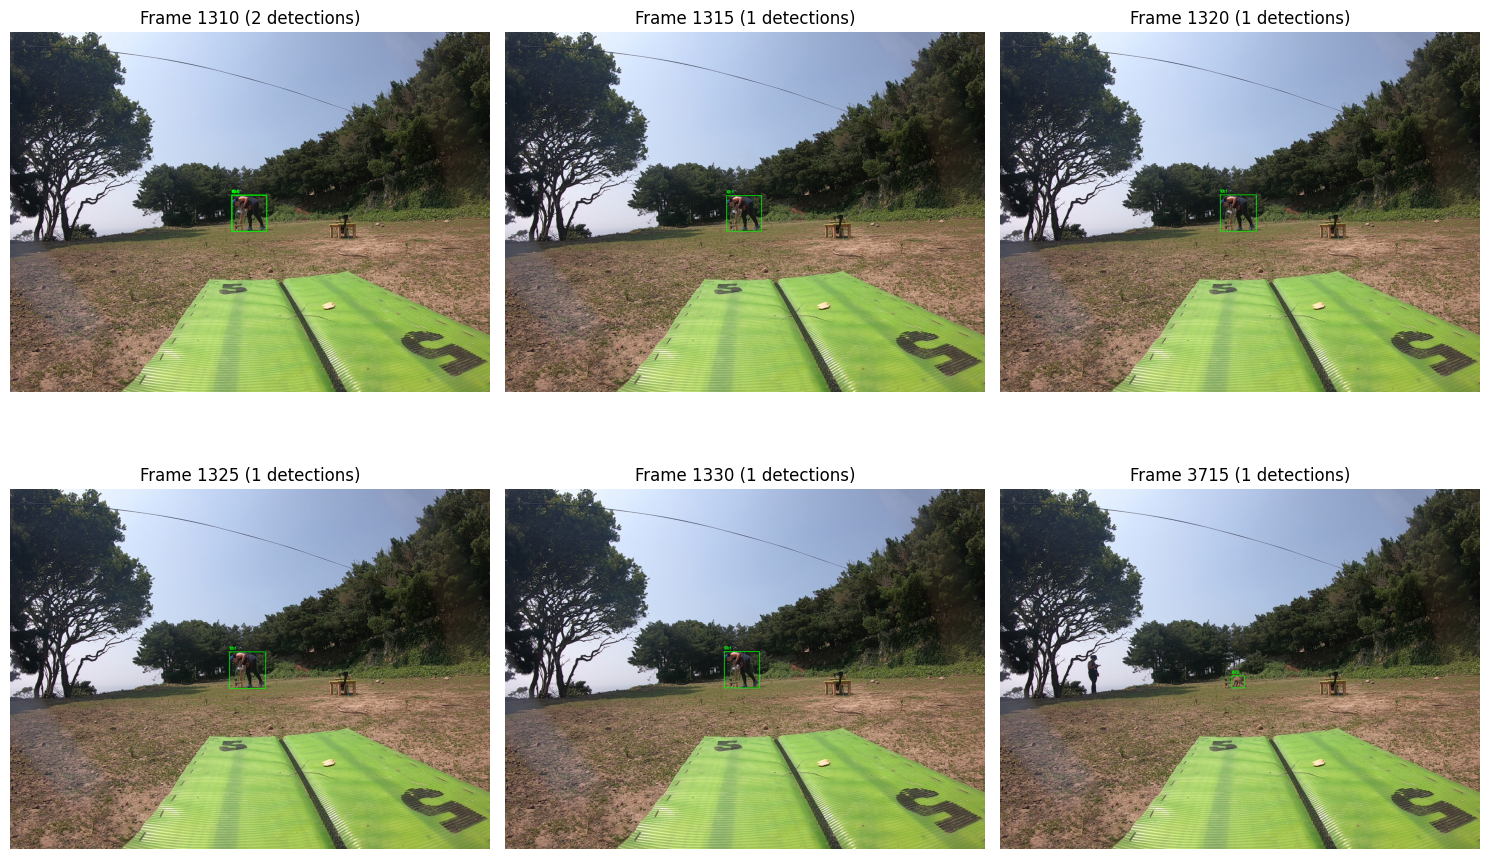

In [9]:
# Show sample frames with detections
if not df_detections.empty and video_files:
    sample_frames = df_detections['frame'].unique()[:6]  # First 6 frames with detections
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    with VideoProcessor(sample_video) as processor:
        for i, frame_num in enumerate(sample_frames):
            ret, frame = processor.read_frame(frame_num)
            if ret:
                # Get detections for this frame
                frame_detections = df_detections[df_detections['frame'] == frame_num]
                
                # Draw bounding boxes
                for _, detection in frame_detections.iterrows():
                    x1, y1, x2, y2 = int(detection['bbox_x1']), int(detection['bbox_y1']), int(detection['bbox_x2']), int(detection['bbox_y2'])
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(frame, f"ID:{int(detection['track_id'])}", 
                              (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
                
                # Convert BGR to RGB for matplotlib
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                axes[i].imshow(frame_rgb)
                axes[i].set_title(f'Frame {frame_num} ({len(frame_detections)} detections)')
                axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

## Summary

This notebook processed the camera trap video and:

1. ✅ Loaded and analyzed video files
2. ✅ Detected potential primates using YOLO
3. ✅ Tracked detections across frames 
4. ✅ Extracted visual features for each tracklet
5. ✅ Saved results for clustering analysis

**Next Steps:**
- Run the clustering notebook to identify individual macaques
- Use the video extraction notebook to create clips for each individual

**Files Created:**
- `../output/detections_*.csv` - Detection results with bounding boxes and tracking
- `../output/tracklet_features_*.npz` - Visual features for each tracklet
- `../output/track_mapping_*.csv` - Track ID to feature mapping